In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Data_set.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()
df["Churn"].value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Data cleaning

In [4]:
df = df.drop(["customerID"],axis = 1)
df["TotalCharges"]= pd.to_numeric(df["TotalCharges"],errors = "coerce")
print("Missing values in TotalCharges:",df["TotalCharges"].isnull().sum())

df = df.dropna(subset = ["TotalCharges"])
print("Final shape:",df.shape)


Missing values in TotalCharges: 11
Final shape: (7032, 20)


In [5]:
df["Churn_Flag"]=df["Churn"].map({"Yes":1,"No":0})
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Flag
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


In [6]:
churn_rate = df["Churn_Flag"].mean()*100
print(f"Overal churn rate:{churn_rate:.2f}%")

Overal churn rate:26.58%


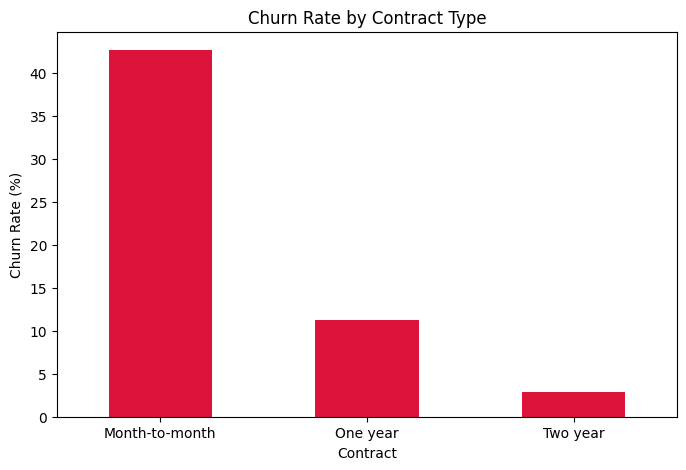

In [7]:
contract_churn_rate = df.groupby("Contract")["Churn_Flag"].mean().sort_values(ascending = False)*100

plt.figure(figsize = (8,5))
contract_churn_rate.plot(kind = "bar",color = "crimson")
plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation = 0)
plt.show()

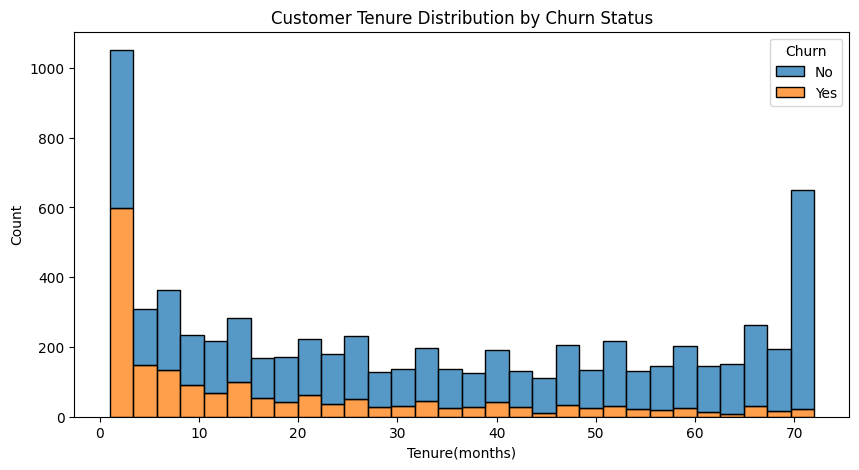

In [8]:
plt.figure(figsize = (10,5))
sns.histplot(data = df, x = "tenure",hue = "Churn",multiple = "stack",bins = 30)
plt.title("Customer Tenure Distribution by Churn Status")
plt.xlabel("Tenure(months)")
plt.show()

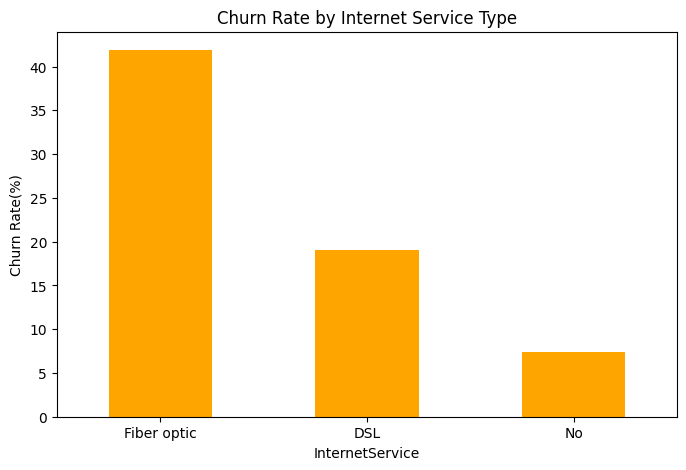

In [9]:
internet_churn = df.groupby("InternetService")['Churn_Flag'].mean().sort_values(ascending = False)*100

plt.figure(figsize = (8,5))
internet_churn.plot(kind = "bar",color = "orange")
plt.title("Churn Rate by Internet Service Type")
plt.ylabel("Churn Rate(%)")
plt.xticks(rotation = 0)
plt.show()

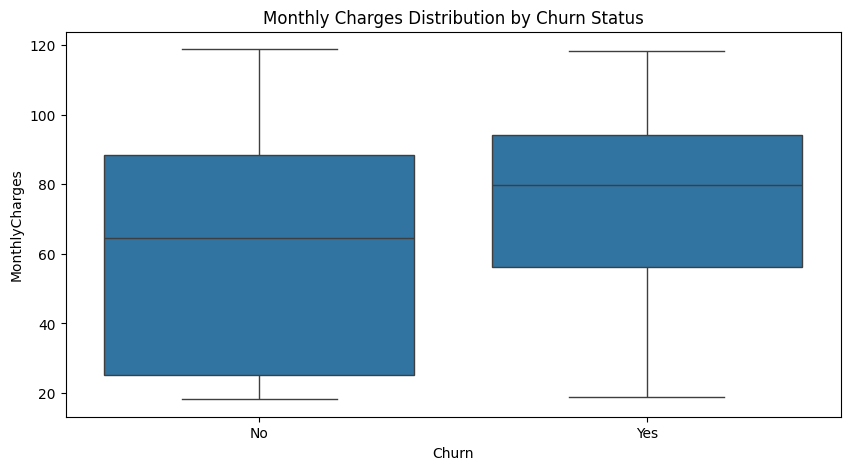

In [10]:
plt.figure(figsize = (10,5))
sns.boxplot(data = df, x = 'Churn',y = 'MonthlyCharges')
plt.title('Monthly Charges Distribution by Churn Status')
plt.show()

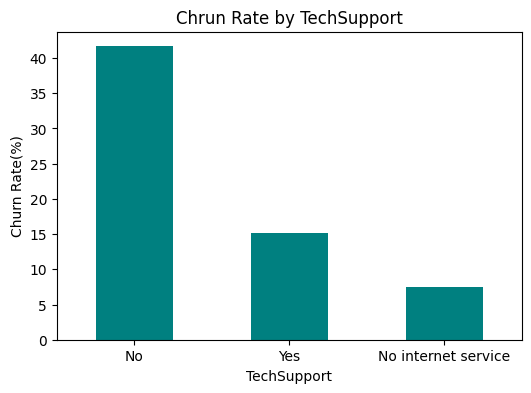

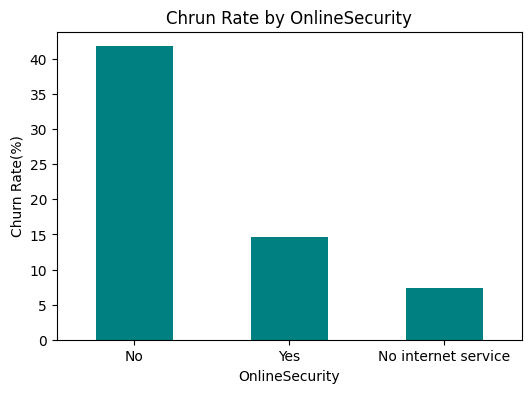

In [14]:
for col in ['TechSupport','OnlineSecurity']:
    rate = df.groupby(col)['Churn_Flag'].mean().sort_values(ascending = False)*100
    plt.figure(figsize = (6,4))
    rate.plot(kind = 'bar',color = 'teal')
    plt.title(f'Chrun Rate by {col}')
    plt.ylabel('Churn Rate(%)')
    plt.xticks(rotation = 0)
    plt.show()

In [19]:
total_customers = len(df)
churned_customers = df['Churn_Flag'].sum()
overall_churn_rate = df['Churn_Flag'].mean()*100
avg_tenure = df['tenure'].mean()
avg_monthly = df['MonthlyCharges'].mean()

print(f"Total Customers:{total_customers}")
print(f"Churned Customers:{churned_customers}")
print(f"Overall Churn Rate:{overall_churn_rate:.2f}%")
print(f"Average Tenure:{avg_tenure:.2f}months")
print(f"Average Monthly Charges:${avg_monthly:.2f}")

Total Customers:7032
Churned Customers:1869
Overall Churn Rate:26.58%
Average Tenure:32.42months
Average Monthly Charges:$64.80


## Key Insights

**Overall:** 26.6% of customers (1,869 of 7,032) have churned, with an average tenure of 32 months and average monthly charges of $64.80.

1. **Contract type is the biggest churn driver.** Month-to-month customers churn at ~42%, versus ~11% on one-year and under 3% on two-year contracts.
2. **Churn happens early.** Most churned customers left within their first few months. Customers who pass the first year rarely leave.
3. **Fiber optic customers churn the most (~42%),** compared with DSL (~19%) and customers with no internet service (~7%), which suggests a pricing or service-quality problem with fiber.
4. **Higher bills go with higher churn.** Churned customers have a noticeably higher median monthly charge than retained customers.
5. **Support services retain customers.** Customers without Tech Support or Online Security churn at ~42%, versus ~15% for those who have them.

## Recommendations

- Offer discounts or incentives to move month-to-month customers onto 1-year or 2-year contracts.
- Build an onboarding and check-in program for the first 3 to 6 months, when churn risk is highest.
- Investigate fiber optic pricing and service quality.
- Bundle Tech Support and Online Security for free or at a low price for new customers, especially on fiber plans.
- Flag high-bill, month-to-month customers as an at-risk segment for proactive retention offers.